<a href="https://colab.research.google.com/github/lucasosl89/bootcamplab/blob/master/FIAP_ANALISE_EXPLORATORIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANÁLISE EXPLORATÓRIA
### Dataset: Brazilian E-Commerce Public Dataset by Olist
### Link do Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
### Objetivo: fazer uma EDA completa
### Foco: investigação, hipóteses, padrões, correlação e causalidade





## 1. IMPORTAÇÃO DAS BIBLIOTECAS

In [ ]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

NameError: name 'kagglehub' is not defined

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12


## 2. LEITURA DOS DADOS


In [ ]:
pedidos = pd.read_csv("olist_orders_dataset.csv")
itens = pd.read_csv("olist_order_items_dataset.csv")
pagamentos = pd.read_csv("olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv("olist_order_reviews_dataset.csv")
clientes = pd.read_csv("olist_customers_dataset.csv")
produtos = pd.read_csv("olist_products_dataset.csv")
vendedores = pd.read_csv("olist_sellers_dataset.csv")
traducao = pd.read_csv("product_category_name_translation.csv")

## 3. PRIMEIRO CONTATO COM AS TABELAS

In [ ]:

print("Pedidos:", pedidos.shape)
print("Itens:", itens.shape)
print("Pagamentos:", pagamentos.shape)
print("Avaliações:", avaliacoes.shape)
print("Clientes:", clientes.shape)
print("Produtos:", produtos.shape)
print("Vendedores:", vendedores.shape)
print("Tradução:", traducao.shape)

pedidos.head()

Pedidos: (99441, 8)
Itens: (112650, 7)
Pagamentos: (103886, 5)
Avaliações: (99224, 7)
Clientes: (99441, 5)
Produtos: (32951, 9)
Vendedores: (3095, 4)
Tradução: (71, 2)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 4. ENTENDENDO A GRANULARIDADE


In [6]:
print("Pedidos únicos em pedidos:", pedidos["order_id"].nunique())
print("Pedidos únicos em itens:", itens["order_id"].nunique())
print("Pedidos únicos em pagamentos:", pagamentos["order_id"].nunique())
print("Pedidos únicos em avaliações:", avaliacoes["order_id"].nunique())

Pedidos únicos em pedidos: 99441
Pedidos únicos em itens: 98666
Pedidos únicos em pagamentos: 99440
Pedidos únicos em avaliações: 98673


## 5. TRATAMENTO DE DATAS

In [7]:


colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(pedidos[coluna], errors="coerce")

## 6. CRIAÇÃO DE VARIÁVEIS DE NEGÓCIO

In [8]:
pedidos["ano_compra"] = pedidos["order_purchase_timestamp"].dt.year
pedidos["mes_compra"] = pedidos["order_purchase_timestamp"].dt.month
pedidos["ano_mes_compra"] = pedidos["order_purchase_timestamp"].dt.to_period("M").astype(str)

pedidos["dia_semana_compra"] = pedidos["order_purchase_timestamp"].dt.day_name()

traducao_dias = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

pedidos["dia_semana_compra"] = pedidos["dia_semana_compra"].map(traducao_dias)

pedidos["hora_compra"] = pedidos["order_purchase_timestamp"].dt.hour

pedidos["tempo_entrega_dias"] = (
    pedidos["order_delivered_customer_date"] - pedidos["order_purchase_timestamp"]
).dt.days

pedidos["atraso_dias"] = (
    pedidos["order_delivered_customer_date"] - pedidos["order_estimated_delivery_date"]
).dt.days

# Importante:
# Se atraso_dias estiver nulo, provavelmente o pedido não foi entregue.
# Nesse caso, não podemos classificá-lo automaticamente como "não atrasado".
pedidos["pedido_atrasado"] = np.where(
    pedidos["atraso_dias"].isna(),
    np.nan,
    np.where(pedidos["atraso_dias"] > 0, 1, 0)
)

## 7. CONSOLIDAÇÃO DAS TABELAS

In [ ]:
pagamentos_agg = (
    pagamentos
    .groupby("order_id")
    .agg(
        valor_pagamento=("payment_value", "sum"),
        qtd_parcelas=("payment_installments", "max"),
        tipos_pagamento=("payment_type", lambda x: ", ".join(x.unique()))
    )
    .reset_index()
)

itens_agg = (
    itens
    .groupby("order_id")
    .agg(
        qtd_itens=("order_item_id", "count"),
        valor_total_produtos=("price", "sum"),
        valor_total_frete=("freight_value", "sum"),
        preco_medio_item=("price", "mean"),
        seller_id=("seller_id", "first"),
        product_id=("product_id", "first")
    )
    .reset_index()
)

avaliacoes_agg = (
    avaliacoes
    .groupby("order_id")
    .agg(
        nota_avaliacao=("review_score", "mean"),
        tem_comentario_avaliacao=("review_comment_message", lambda x: x.notna().max())
    )
    .reset_index()
)

df = (
    pedidos
    .merge(itens_agg, on="order_id", how="left")
    .merge(pagamentos_agg, on="order_id", how="left")
    .merge(avaliacoes_agg, on="order_id", how="left")
    .merge(clientes, on="customer_id", how="left")
    .merge(produtos, on="product_id", how="left")
    .merge(vendedores, on="seller_id", how="left")
    .merge(traducao, on="product_category_name", how="left")
)

## 8. RENOMEANDO AS COLUNAS PARA PORTUGUÊS

In [ ]:
df = df.rename(columns={
    "order_id": "id_pedido",
    "customer_id": "id_cliente",
    "order_status": "status_pedido",
    "order_purchase_timestamp": "data_compra",
    "order_approved_at": "data_aprovacao",
    "order_delivered_carrier_date": "data_envio_transportadora",
    "order_delivered_customer_date": "data_entrega_cliente",
    "order_estimated_delivery_date": "data_entrega_estimada",

    "customer_unique_id": "id_cliente_unico",
    "customer_zip_code_prefix": "prefixo_cep_cliente",
    "customer_city": "cidade_cliente",
    "customer_state": "estado_cliente",

    "seller_id": "id_vendedor",
    "seller_zip_code_prefix": "prefixo_cep_vendedor",
    "seller_city": "cidade_vendedor",
    "seller_state": "estado_vendedor",

    "product_id": "id_produto",
    "product_category_name": "categoria_produto_original",
    "product_category_name_english": "categoria_produto",
    "product_name_lenght": "tamanho_nome_produto",
    "product_description_lenght": "tamanho_descricao_produto",
    "product_photos_qty": "qtd_fotos_produto",
    "product_weight_g": "peso_produto_g",
    "product_length_cm": "comprimento_produto_cm",
    "product_height_cm": "altura_produto_cm",
    "product_width_cm": "largura_produto_cm"
})

print(df.shape)
df.head()

df_entregues = df[df["status_pedido"] == "delivered"].copy()

print("Base completa:", df.shape)
print("Base apenas com pedidos entregues:", df_entregues.shape)

(99441, 43)
Base completa: (99441, 43)
Base apenas com pedidos entregues: (96478, 43)


## 9. VISÃO GERAL DA BASE FINAL


In [ ]:
df.info()
df.describe(include="all").T.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_pedido                   99441 non-null  object        
 1   id_cliente                  99441 non-null  object        
 2   status_pedido               99441 non-null  object        
 3   data_compra                 99441 non-null  datetime64[ns]
 4   data_aprovacao              99281 non-null  datetime64[ns]
 5   data_envio_transportadora   97658 non-null  datetime64[ns]
 6   data_entrega_cliente        96476 non-null  datetime64[ns]
 7   data_entrega_estimada       99441 non-null  datetime64[ns]
 8   ano_compra                  99441 non-null  int32         
 9   mes_compra                  99441 non-null  int32         
 10  ano_mes_compra              99441 non-null  object        
 11  dia_semana_compra           99441 non-null  object    

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_pedido,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_cliente,99441,99441,edb027a75a1449115f6b43211ae02a24,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_pedido,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_compra,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
data_aprovacao,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800128,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06,NaN
data_envio_transportadora,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278656,2016-10-08 10:34:01,2017-09-15 22:28:50.249999872,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28,NaN
data_entrega_cliente,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542272,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46,NaN
data_entrega_estimada,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111232,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
ano_compra,"99,441.00",NaN,NaN,NaN,"2,017.54","2,016.00","2,017.00","2,018.00","2,018.00","2,018.00",0.51
mes_compra,"99,441.00",NaN,NaN,NaN,6.03,1.00,3.00,6.00,8.00,12.00,3.23


## 10. VALORES NULOS


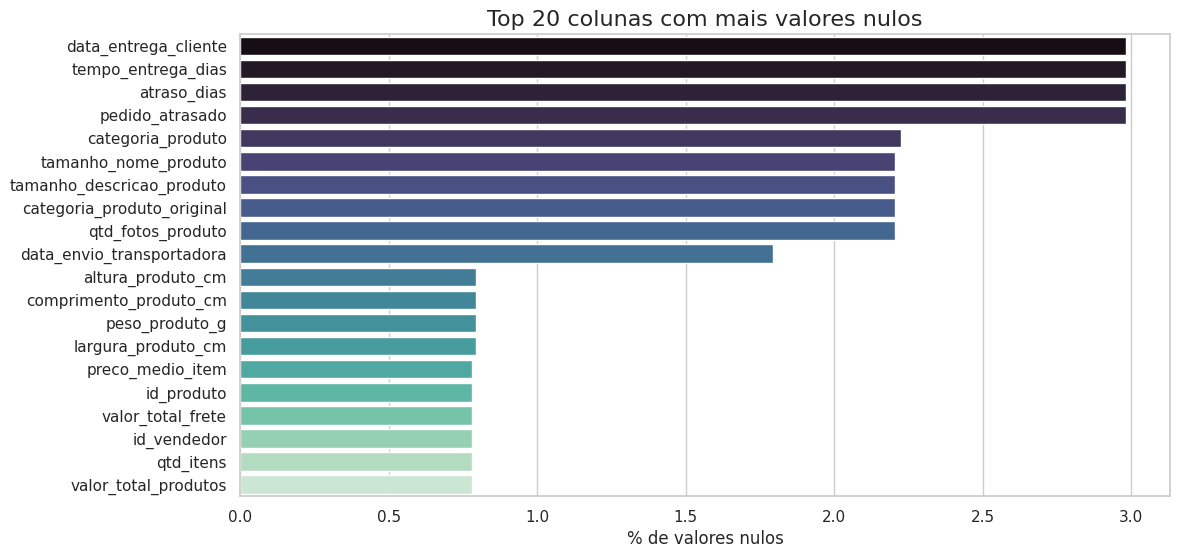

In [ ]:
nulos = (
    df.isna().sum()
    .sort_values(ascending=False)
    .reset_index()
)

nulos.columns = ["coluna", "qtd_nulos"]
nulos["perc_nulos"] = nulos["qtd_nulos"] / len(df) * 100

nulos.head(20)


plt.figure(figsize=(12, 6))
sns.barplot(
    data=nulos.query("qtd_nulos > 0").head(20),
    x="perc_nulos",
    y="coluna",
    hue="coluna",
    palette="mako",
    legend=False
)
plt.title("Top 20 colunas com mais valores nulos")
plt.xlabel("% de valores nulos")
plt.ylabel("")
plt.show()

## 11. STATUS DOS PEDIDOS


In [ ]:
status_pedido = (
    df["status_pedido"]
    .value_counts()
    .reset_index()
)

status_pedido.columns = ["status_pedido", "qtd"]

fig = px.bar(
    status_pedido,
    x="status_pedido",
    y="qtd",
    text="qtd",
    title="Quantidade de pedidos por status",
    color="qtd",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Status do pedido",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()

## 12. EVOLUÇÃO DE PEDIDOS AO LONGO DO TEMPO


In [ ]:
pedidos_mes = (
    df
    .groupby("ano_mes_compra")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        receita=("valor_pagamento", "sum"),
        ticket_medio=("valor_pagamento", "mean")
    )
    .reset_index()
)

fig = px.line(
    pedidos_mes,
    x="ano_mes_compra",
    y="qtd_pedidos",
    markers=True,
    title="Evolução mensal da quantidade de pedidos"
)

fig.update_layout(
    xaxis_title="Mês",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()


fig = px.line(
    pedidos_mes,
    x="ano_mes_compra",
    y="receita",
    markers=True,
    title="Evolução mensal da receita"
)

fig.update_layout(
    xaxis_title="Mês",
    yaxis_title="Receita",
    template="plotly_white"
)

fig.show()

## 13. DISTRIBUIÇÃO DO VALOR DOS PEDIDOS


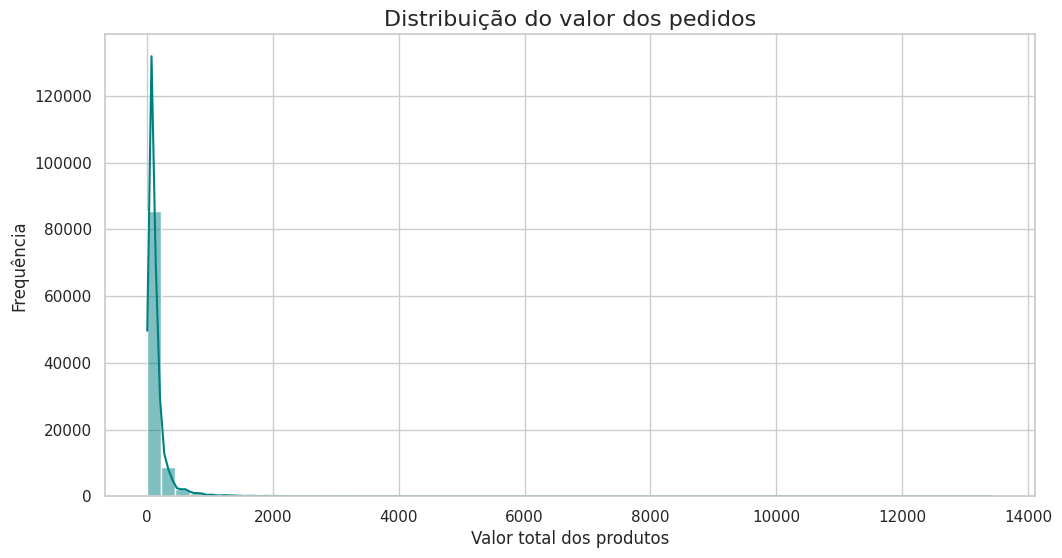

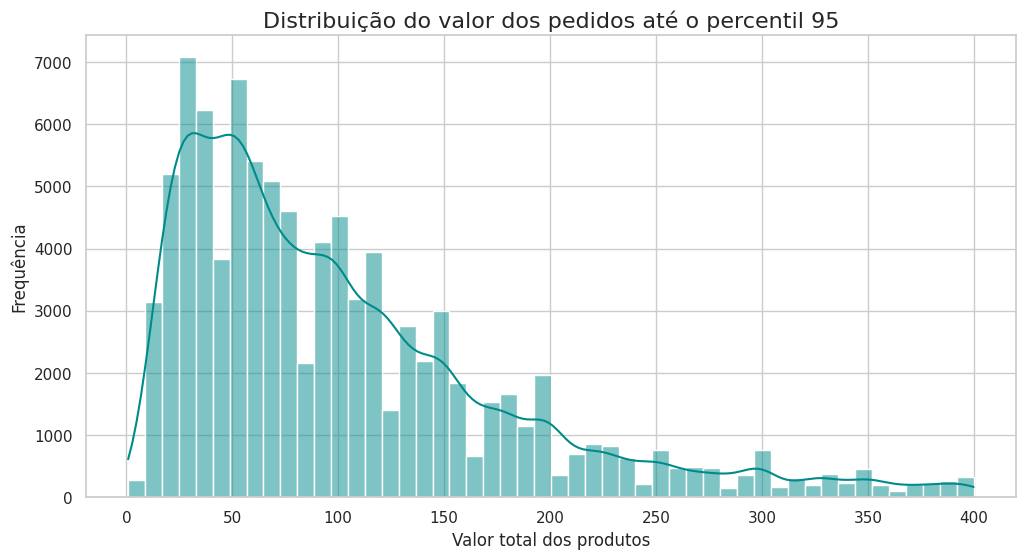

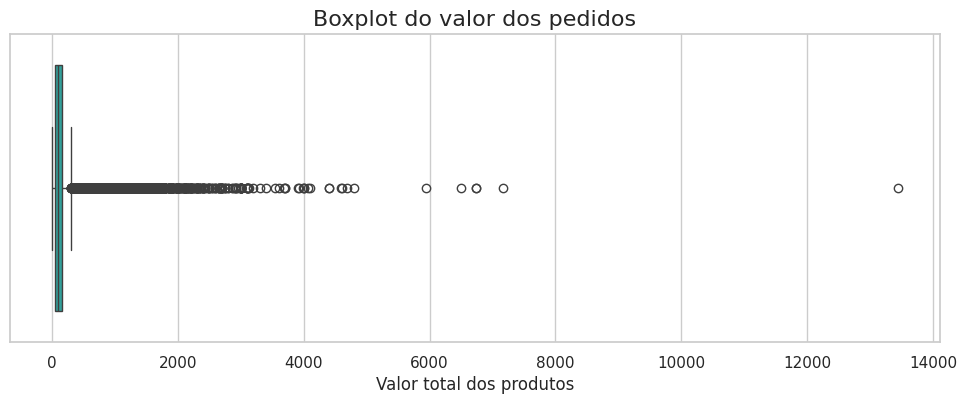

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df["valor_total_produtos"], bins=60, kde=True, color="teal")
plt.title("Distribuição do valor dos pedidos")
plt.xlabel("Valor total dos produtos")
plt.ylabel("Frequência")
plt.show()


limite_preco = df["valor_total_produtos"].quantile(0.95)

plt.figure(figsize=(12, 6))
sns.histplot(
    df[df["valor_total_produtos"] <= limite_preco]["valor_total_produtos"],
    bins=50,
    kde=True,
    color="darkcyan"
)
plt.title("Distribuição do valor dos pedidos até o percentil 95")
plt.xlabel("Valor total dos produtos")
plt.ylabel("Frequência")
plt.show()


plt.figure(figsize=(12, 4))
sns.boxplot(x=df["valor_total_produtos"], color="lightseagreen")
plt.title("Boxplot do valor dos pedidos")
plt.xlabel("Valor total dos produtos")
plt.show()

## 14. DISTRIBUIÇÃO DO FRETE


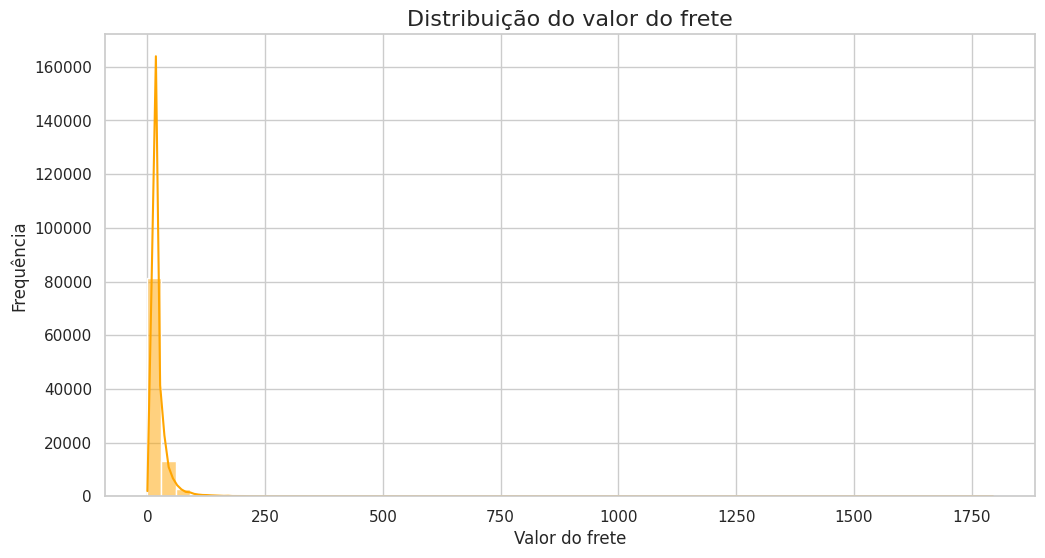

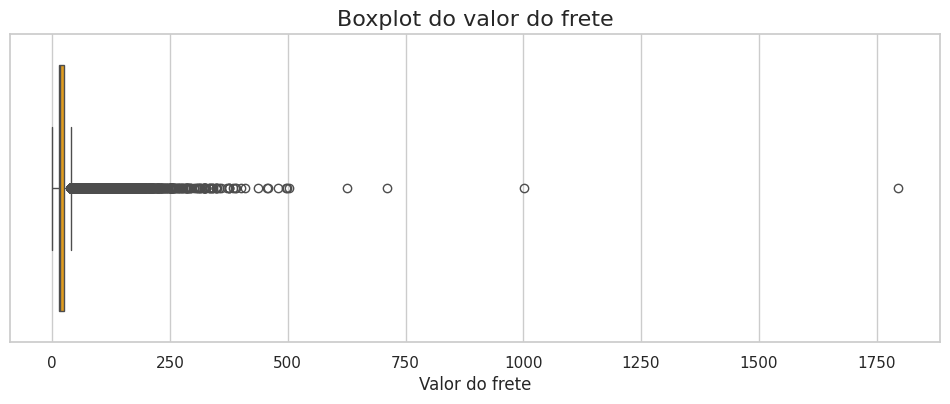

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df["valor_total_frete"], bins=60, kde=True, color="orange")
plt.title("Distribuição do valor do frete")
plt.xlabel("Valor do frete")
plt.ylabel("Frequência")
plt.show()


plt.figure(figsize=(12, 4))
sns.boxplot(x=df["valor_total_frete"], color="orange")
plt.title("Boxplot do valor do frete")
plt.xlabel("Valor do frete")
plt.show()

## 15. RELAÇÃO ENTRE PREÇO E FRETE


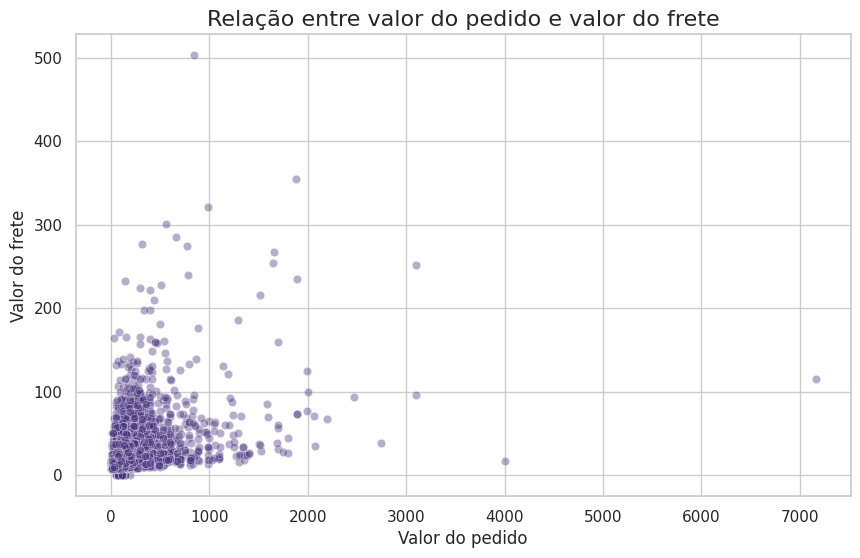

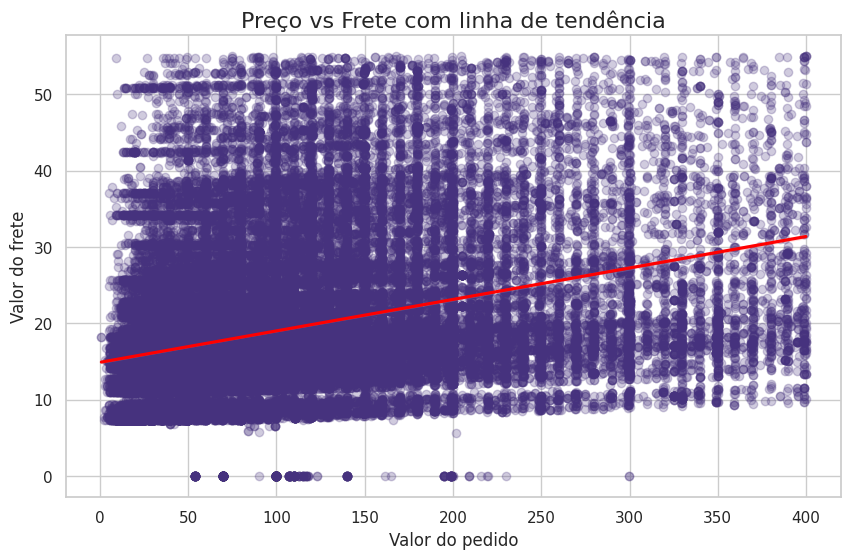

In [ ]:
amostra = df.sample(min(8000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=amostra,
    x="valor_total_produtos",
    y="valor_total_frete",
    alpha=0.4
)
plt.title("Relação entre valor do pedido e valor do frete")
plt.xlabel("Valor do pedido")
plt.ylabel("Valor do frete")
plt.show()


df_limite = df[
    (df["valor_total_produtos"] <= df["valor_total_produtos"].quantile(0.95)) &
    (df["valor_total_frete"] <= df["valor_total_frete"].quantile(0.95))
]

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_limite,
    x="valor_total_produtos",
    y="valor_total_frete",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Preço vs Frete com linha de tendência")
plt.xlabel("Valor do pedido")
plt.ylabel("Valor do frete")
plt.show()

## 16. TEMPO DE ENTREGA


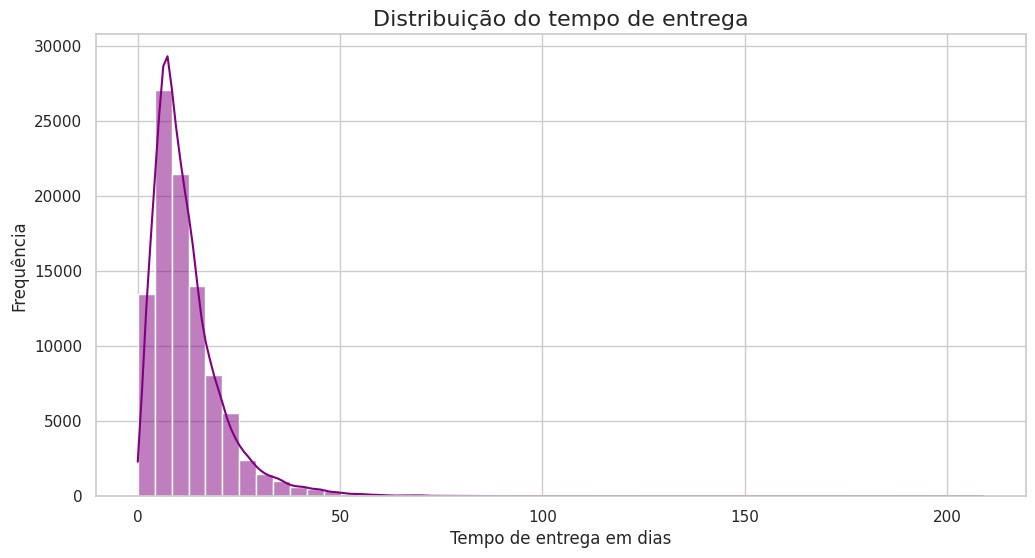

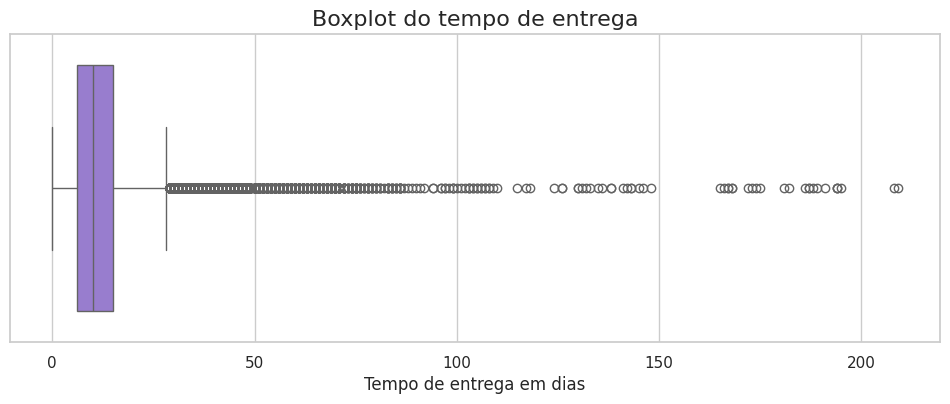

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df["tempo_entrega_dias"].dropna(), bins=50, kde=True, color="purple")
plt.title("Distribuição do tempo de entrega")
plt.xlabel("Tempo de entrega em dias")
plt.ylabel("Frequência")
plt.show()


plt.figure(figsize=(12, 4))
sns.boxplot(x=df["tempo_entrega_dias"], color="mediumpurple")
plt.title("Boxplot do tempo de entrega")
plt.xlabel("Tempo de entrega em dias")
plt.show()

## 17. ATRASO NA ENTREGA


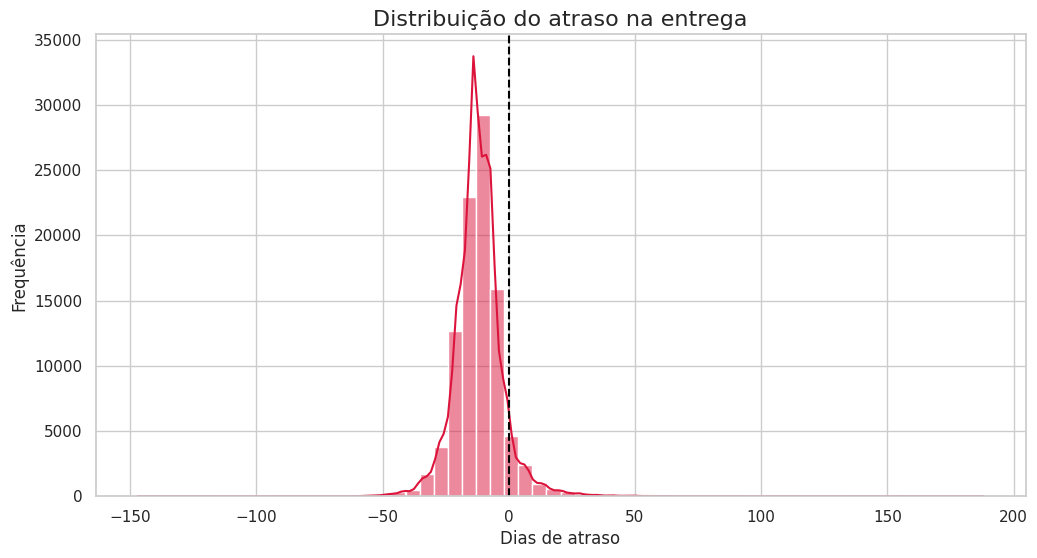

Percentual de pedidos atrasados entre pedidos entregues: 6.77%


In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_entregues["atraso_dias"].dropna(), bins=60, kde=True, color="crimson")
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribuição do atraso na entrega")
plt.xlabel("Dias de atraso")
plt.ylabel("Frequência")
plt.show()


perc_atraso = df_entregues["pedido_atrasado"].mean() * 100

print(f"Percentual de pedidos atrasados entre pedidos entregues: {perc_atraso:.2f}%")


contagem_atraso = (
    df_entregues["pedido_atrasado"]
    .map({0: "No prazo ou antecipado", 1: "Atrasado"})
    .value_counts()
    .reset_index()
)

contagem_atraso.columns = ["status_entrega", "qtd"]

fig = px.pie(
    contagem_atraso,
    names="status_entrega",
    values="qtd",
    title="Participação de pedidos atrasados entre pedidos entregues"
)

fig.update_layout(template="plotly_white")
fig.show()

## 18. NOTA DE AVALIAÇÃO



In [ ]:
notas = (
    df["nota_avaliacao"]
    .value_counts()
    .sort_index()
    .reset_index()
)

notas.columns = ["nota_avaliacao", "qtd"]

fig = px.bar(
    notas,
    x="nota_avaliacao",
    y="qtd",
    text="qtd",
    color="nota_avaliacao",
    color_continuous_scale="RdYlGn",
    title="Distribuição das notas de avaliação"
)

fig.update_layout(
    xaxis_title="Nota de avaliação",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()

## 19. ATRASO VS NOTA DE AVALIAÇÃO


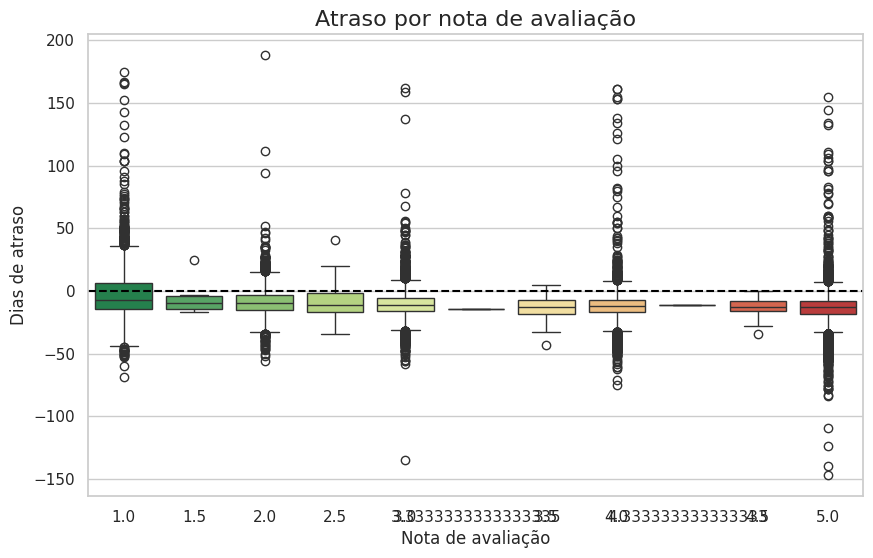

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_entregues,
    x="nota_avaliacao",
    y="atraso_dias",
    palette="RdYlGn_r"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Atraso por nota de avaliação")
plt.xlabel("Nota de avaliação")
plt.ylabel("Dias de atraso")
plt.show()


avaliacao_atraso = (
    df_entregues
    .groupby("nota_avaliacao")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        atraso_medio=("atraso_dias", "mean"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        frete_medio=("valor_total_frete", "mean"),
        preco_medio=("valor_total_produtos", "mean"),
        perc_atraso=("pedido_atrasado", "mean")
    )
    .reset_index()
)

avaliacao_atraso["perc_atraso"] = avaliacao_atraso["perc_atraso"] * 100

avaliacao_atraso


fig = px.line(
    avaliacao_atraso,
    x="nota_avaliacao",
    y="perc_atraso",
    markers=True,
    title="Percentual de atraso por nota de avaliação"
)

fig.update_layout(
    xaxis_title="Nota de avaliação",
    yaxis_title="% de pedidos atrasados",
    template="plotly_white"
)

fig.show()

## 20. FORMA DE PAGAMENTO


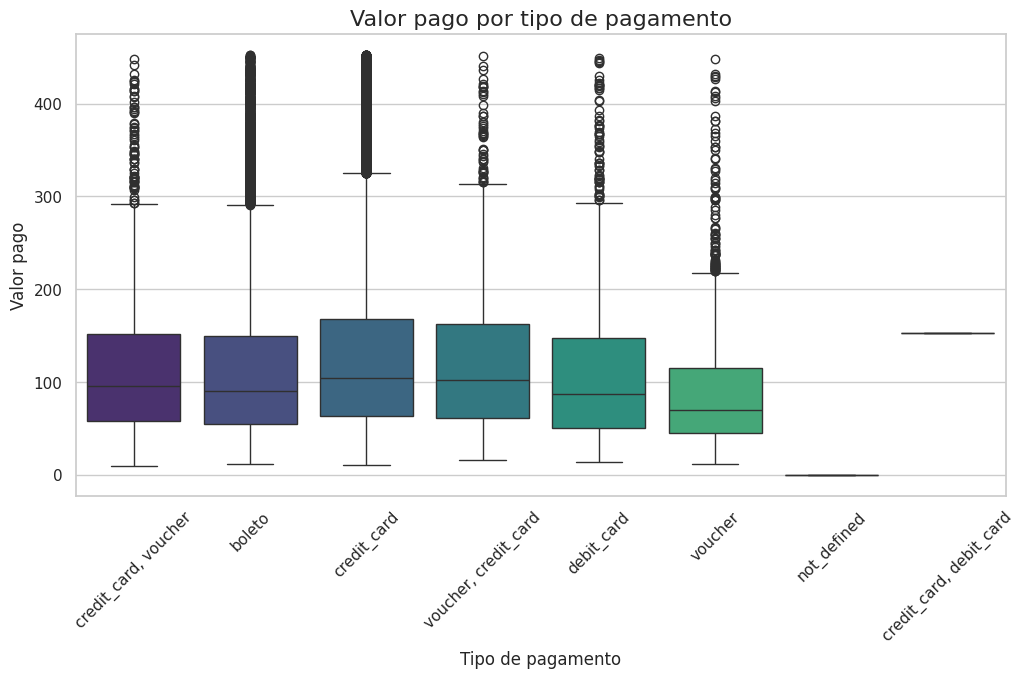

In [ ]:
pagamento_tipo = (
    pagamentos
    .groupby("payment_type")
    .agg(
        qtd_pagamentos=("order_id", "count"),
        valor_total=("payment_value", "sum"),
        valor_medio=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("qtd_pagamentos", ascending=False)
)

pagamento_tipo = pagamento_tipo.rename(columns={
    "payment_type": "tipo_pagamento"
})

pagamento_tipo


fig = px.bar(
    pagamento_tipo,
    x="tipo_pagamento",
    y="qtd_pagamentos",
    text="qtd_pagamentos",
    color="qtd_pagamentos",
    color_continuous_scale="Blues",
    title="Quantidade de pagamentos por tipo"
)

fig.update_layout(
    xaxis_title="Tipo de pagamento",
    yaxis_title="Quantidade",
    template="plotly_white"
)

fig.show()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df["valor_pagamento"] <= df["valor_pagamento"].quantile(0.95)],
    x="tipos_pagamento",
    y="valor_pagamento",
    palette="viridis"
)
plt.title("Valor pago por tipo de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor pago")
plt.xticks(rotation=45)
plt.show()

## 21. ANÁLISE POR ESTADO DO CLIENTE



In [ ]:
analise_estado = (
    df
    .groupby("estado_cliente")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        receita=("valor_pagamento", "sum"),
        ticket_medio=("valor_pagamento", "mean"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        atraso_medio=("atraso_dias", "mean"),
        perc_atraso=("pedido_atrasado", "mean"),
        nota_media=("nota_avaliacao", "mean")
    )
    .reset_index()
)

analise_estado["perc_atraso"] = analise_estado["perc_atraso"] * 100

analise_estado = analise_estado.sort_values("qtd_pedidos", ascending=False)

analise_estado.head(10)


fig = px.bar(
    analise_estado.head(15),
    x="estado_cliente",
    y="qtd_pedidos",
    text="qtd_pedidos",
    color="qtd_pedidos",
    color_continuous_scale="Viridis",
    title="Top 15 estados por quantidade de pedidos"
)

fig.update_layout(
    xaxis_title="Estado do cliente",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()


fig = px.scatter(
    analise_estado,
    x="tempo_entrega_medio",
    y="nota_media",
    size="qtd_pedidos",
    color="perc_atraso",
    hover_name="estado_cliente",
    title="Estados: tempo médio de entrega vs avaliação média",
    color_continuous_scale="RdYlGn_r"
)

fig.update_layout(
    xaxis_title="Tempo médio de entrega",
    yaxis_title="Nota média",
    template="plotly_white"
)

fig.show()

## 22. CATEGORIAS DE PRODUTO


In [ ]:
analise_categoria = (
    df
    .groupby("categoria_produto")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        receita=("valor_pagamento", "sum"),
        preco_medio=("valor_total_produtos", "mean"),
        frete_medio=("valor_total_frete", "mean"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        perc_atraso=("pedido_atrasado", "mean"),
        nota_media=("nota_avaliacao", "mean")
    )
    .reset_index()
)

analise_categoria["perc_atraso"] = analise_categoria["perc_atraso"] * 100

analise_categoria = analise_categoria.sort_values("qtd_pedidos", ascending=False)

analise_categoria.head(15)


top_categorias = analise_categoria.head(15)

fig = px.bar(
    top_categorias.sort_values("qtd_pedidos"),
    x="qtd_pedidos",
    y="categoria_produto",
    orientation="h",
    color="qtd_pedidos",
    color_continuous_scale="Viridis",
    title="Top 15 categorias por quantidade de pedidos"
)

fig.update_layout(
    xaxis_title="Quantidade de pedidos",
    yaxis_title="Categoria",
    template="plotly_white"
)

fig.show()


fig = px.scatter(
    analise_categoria.query("qtd_pedidos >= 100"),
    x="perc_atraso",
    y="nota_media",
    size="qtd_pedidos",
    color="receita",
    hover_name="categoria_produto",
    title="Categorias: atraso vs avaliação média",
    color_continuous_scale="Plasma"
)

fig.update_layout(
    xaxis_title="% de atraso",
    yaxis_title="Nota média",
    template="plotly_white"
)

fig.show()

## 23. ANÁLISE DE HORÁRIO E DIA DA SEMANA


In [ ]:
analise_hora = (
    df
    .groupby("hora_compra")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        ticket_medio=("valor_pagamento", "mean")
    )
    .reset_index()
)

fig = px.line(
    analise_hora,
    x="hora_compra",
    y="qtd_pedidos",
    markers=True,
    title="Quantidade de pedidos por hora do dia"
)

fig.update_layout(
    xaxis_title="Hora da compra",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()


ordem_dias = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo"
]

analise_dia = (
    df
    .groupby("dia_semana_compra")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        ticket_medio=("valor_pagamento", "mean")
    )
    .reindex(ordem_dias)
    .reset_index()
)

fig = px.bar(
    analise_dia,
    x="dia_semana_compra",
    y="qtd_pedidos",
    text="qtd_pedidos",
    color="qtd_pedidos",
    color_continuous_scale="Viridis",
    title="Quantidade de pedidos por dia da semana"
)

fig.update_layout(
    xaxis_title="Dia da semana",
    yaxis_title="Quantidade de pedidos",
    template="plotly_white"
)

fig.show()

## 24. MAPA DE CALOR: DIA DA SEMANA X HORA


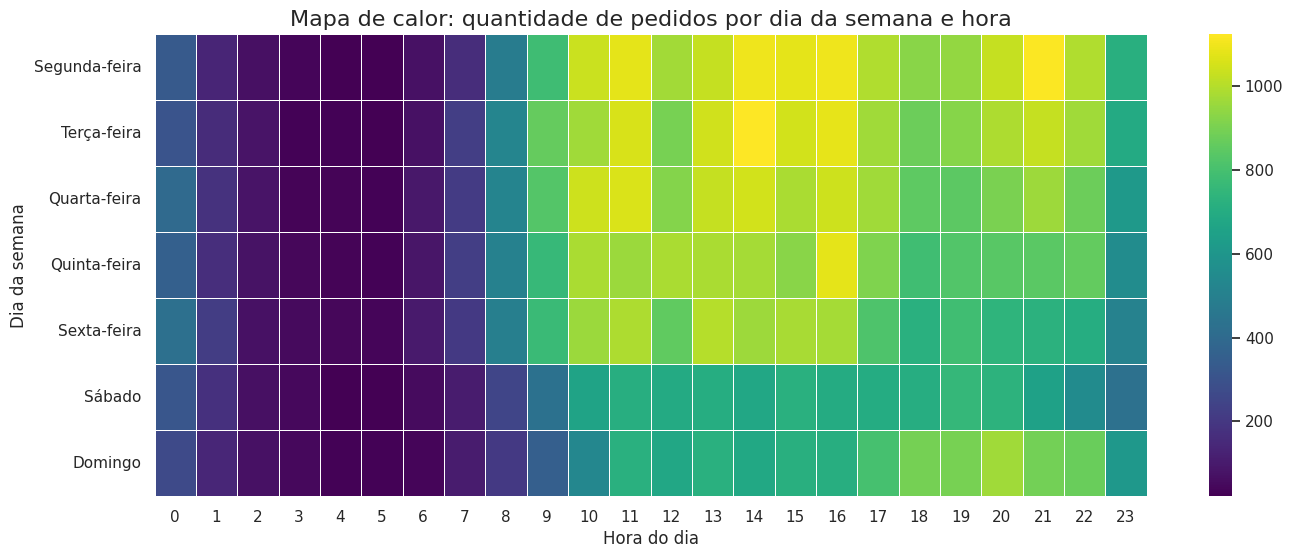

In [ ]:
mapa_calor = (
    df
    .groupby(["dia_semana_compra", "hora_compra"])
    .agg(qtd_pedidos=("id_pedido", "nunique"))
    .reset_index()
)

mapa_calor_pivot = mapa_calor.pivot(
    index="dia_semana_compra",
    columns="hora_compra",
    values="qtd_pedidos"
).reindex(ordem_dias)

plt.figure(figsize=(16, 6))
sns.heatmap(
    mapa_calor_pivot,
    cmap="viridis",
    linewidths=0.5
)
plt.title("Mapa de calor: quantidade de pedidos por dia da semana e hora")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.show()

## 25. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS



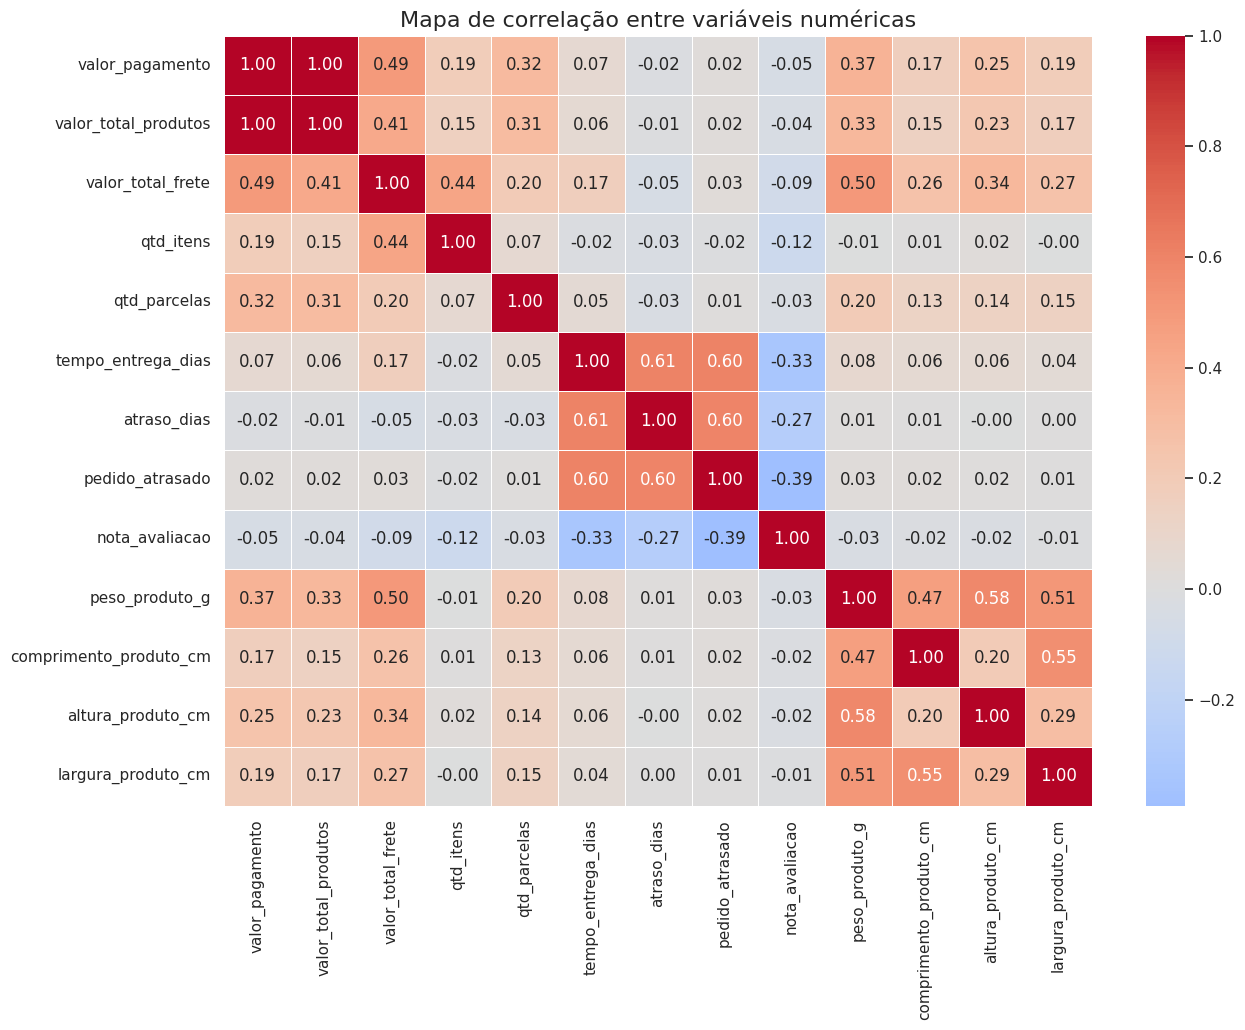

In [ ]:
colunas_numericas = [
    "valor_pagamento",
    "valor_total_produtos",
    "valor_total_frete",
    "qtd_itens",
    "qtd_parcelas",
    "tempo_entrega_dias",
    "atraso_dias",
    "pedido_atrasado",
    "nota_avaliacao",
    "peso_produto_g",
    "comprimento_produto_cm",
    "altura_produto_cm",
    "largura_produto_cm"
]

base_correlacao = df[colunas_numericas].copy()

correlacao = base_correlacao.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Mapa de correlação entre variáveis numéricas")
plt.show()

## 26. CORRELAÇÃO ESPECÍFICA COM NOTA DE AVALIAÇÃO


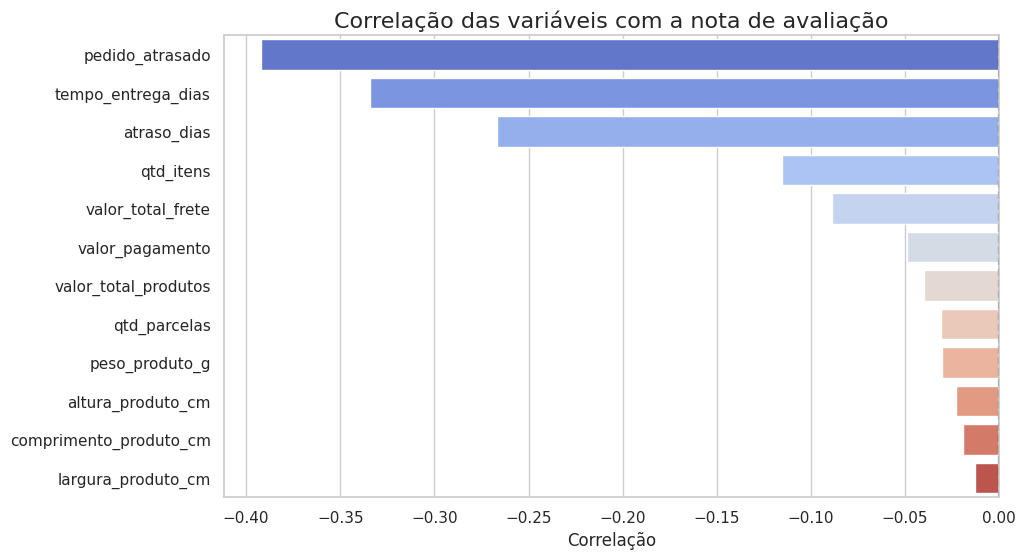

In [ ]:
corr_nota = (
    correlacao["nota_avaliacao"]
    .drop("nota_avaliacao")
    .sort_values()
    .reset_index()
)

corr_nota.columns = ["variavel", "correlacao_com_nota"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_nota,
    x="correlacao_com_nota",
    y="variavel",
    hue="variavel",
    palette="coolwarm",
    legend=False
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Correlação das variáveis com a nota de avaliação")
plt.xlabel("Correlação")
plt.ylabel("")
plt.show()

# 27. RELAÇÃO NÃO SIGNIFICA CAUSA
### Exemplo didático:
##
### Se atraso está correlacionado com nota baixa,
### isso NÃO prova sozinho que atraso causa nota baixa.
### Pode haver variáveis intermediárias:
### - categoria do produto
### - região
### - vendedor
### - valor do frete
### - tipo de entrega
### - perfil do cliente
##
### Na EDA, levantamos hipóteses.
### Para afirmar causa, precisaríamos de desenho causal,
### experimento, quase-experimento ou controles mais fortes.

## 28. COMPARAÇÃO SIMPLES: ATRASADO VS NÃO ATRASADO

In [ ]:
atraso_nota = (
    df_entregues
    .groupby("pedido_atrasado")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        nota_media=("nota_avaliacao", "mean"),
        mediana_nota=("nota_avaliacao", "median"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        atraso_medio=("atraso_dias", "mean"),
        ticket_medio=("valor_pagamento", "mean")
    )
    .reset_index()
)

atraso_nota["status_entrega"] = atraso_nota["pedido_atrasado"].map({
    0: "No prazo ou antecipado",
    1: "Atrasado"
})

atraso_nota


fig = px.bar(
    atraso_nota,
    x="status_entrega",
    y="nota_media",
    text="nota_media",
    color="status_entrega",
    title="Nota média: pedidos atrasados vs não atrasados"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

fig.update_layout(
    xaxis_title="Status da entrega",
    yaxis_title="Nota média de avaliação",
    template="plotly_white",
    showlegend=False
)

fig.show()

## 29. CONTROLANDO UM POUCO MELHOR: COMPARAÇÃO POR ESTADO

In [ ]:
estado_atraso_nota = (
    df_entregues
    .groupby(["estado_cliente", "pedido_atrasado"])
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        nota_media=("nota_avaliacao", "mean")
    )
    .reset_index()
)

estados_validos = (
    df_entregues
    .groupby("estado_cliente")
    .agg(qtd=("id_pedido", "nunique"))
    .query("qtd >= 500")
    .index
)

estado_atraso_nota = estado_atraso_nota[
    estado_atraso_nota["estado_cliente"].isin(estados_validos)
]

estado_atraso_nota["status_entrega"] = estado_atraso_nota["pedido_atrasado"].map({
    0: "No prazo ou antecipado",
    1: "Atrasado"
})

fig = px.bar(
    estado_atraso_nota,
    x="estado_cliente",
    y="nota_media",
    color="status_entrega",
    barmode="group",
    title="Nota média por estado: atrasado vs não atrasado"
)

fig.update_layout(
    xaxis_title="Estado",
    yaxis_title="Nota média",
    template="plotly_white"
)

fig.show()

## 30. CONTROLANDO POR CATEGORIA

In [ ]:
categoria_atraso_nota = (
    df_entregues
    .groupby(["categoria_produto", "pedido_atrasado"])
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        nota_media=("nota_avaliacao", "mean")
    )
    .reset_index()
)

categorias_validas = (
    df_entregues
    .groupby("categoria_produto")
    .agg(qtd=("id_pedido", "nunique"))
    .query("qtd >= 500")
    .index
)

categoria_atraso_nota = categoria_atraso_nota[
    categoria_atraso_nota["categoria_produto"].isin(categorias_validas)
]

categoria_atraso_nota["status_entrega"] = categoria_atraso_nota["pedido_atrasado"].map({
    0: "No prazo ou antecipado",
    1: "Atrasado"
})

fig = px.bar(
    categoria_atraso_nota,
    x="categoria_produto",
    y="nota_media",
    color="status_entrega",
    barmode="group",
    title="Nota média por categoria: atrasado vs não atrasado"
)

fig.update_layout(
    xaxis_title="Categoria",
    yaxis_title="Nota média",
    template="plotly_white"
)

fig.update_xaxes(tickangle=45)

fig.show()

## 31. MATRIZ DE INSIGHTS

In [ ]:
tabela_insights = (
    df
    .groupby("categoria_produto")
    .agg(
        qtd_pedidos=("id_pedido", "nunique"),
        receita=("valor_pagamento", "sum"),
        nota_media=("nota_avaliacao", "mean"),
        atraso_medio=("atraso_dias", "mean"),
        perc_atraso=("pedido_atrasado", "mean"),
        frete_medio=("valor_total_frete", "mean"),
        ticket_medio=("valor_pagamento", "mean")
    )
    .reset_index()
)

tabela_insights["perc_atraso"] = tabela_insights["perc_atraso"] * 100

tabela_insights = tabela_insights.query("qtd_pedidos >= 300")

tabela_insights = tabela_insights.sort_values(
    ["nota_media", "perc_atraso"],
    ascending=[True, False]
)

tabela_insights.head(20)

,categoria_produto,qtd_pedidos,receita,nota_media,atraso_medio,perc_atraso,frete_medio,ticket_medio
57,office_furniture,1265,"341,428.34",3.62,-11.73,8.11,53.95,269.90
4,audio,346,"56,997.29",3.84,-10.01,11.92,16.42,164.73
47,home_confort,375,"67,961.48",3.88,-9.86,9.46,23.60,181.23
7,bed_bath_table,9311,"1,240,930.24",3.98,-11.35,7.52,21.97,133.28
68,telephony,4182,"395,290.06",4.01,-11.24,7.14,17.02,94.52
39,furniture_decor,6355,"906,602.02",4.02,-12.28,7.18,27.21,142.66
15,computers_accessories,6660,"1,057,630.10",4.03,-12.36,6.42,22.06,158.80
48,home_construction,473,"96,259.05",4.03,-11.26,6.22,28.73,203.51
40,furniture_living_room,417,"87,574.32",4.05,-11.66,7.58,43.46,210.01
6,baby,2839,"479,639.72",4.06,-11.43,8.18,24.10,168.95


## 32. QUADRANTE: CATEGORIAS CRÍTICAS

In [ ]:
base_quadrante = tabela_insights.copy()

media_atraso = base_quadrante["perc_atraso"].mean()
media_nota = base_quadrante["nota_media"].mean()

fig = px.scatter(
    base_quadrante,
    x="perc_atraso",
    y="nota_media",
    size="qtd_pedidos",
    color="receita",
    hover_name="categoria_produto",
    title="Quadrante de categorias: atraso vs avaliação",
    color_continuous_scale="Plasma"
)

fig.add_vline(x=media_atraso, line_dash="dash", line_color="gray")
fig.add_hline(y=media_nota, line_dash="dash", line_color="gray")

fig.update_layout(
    xaxis_title="% de pedidos atrasados",
    yaxis_title="Nota média",
    template="plotly_white"
)

fig.show()


# 33. CONCLUSÕES GUIADAS
## Perguntas para discussão:
### 1. Quais variáveis parecem mais relacionadas com a avaliação?
### 2. O atraso parece afetar a nota?
### 3. Essa relação é igual em todos os estados?
### 4. Essa relação é igual em todas as categorias?
### 5. Podemos afirmar causalidade?
### 6. Que outros dados seriam necessários para investigar melhor?

# 34. EXERCÍCIOS

## Exercício 1:
### Calcule o ticket médio geral dos pedidos.

## Exercício 2:
### Calcule o ticket médio por estado do cliente.

## Exercício 3:
### Faça um gráfico com os 10 estados com maior quantidade de pedidos.

## Exercício 4:
### Calcule o percentual de pedidos atrasados por estado.


## Exercício 5:
### Faça um gráfico comparando nota média entre pedidos atrasados e não atrasados.

## Exercício 6:
### Analise as 10 categorias com maior volume de pedidos.

## Exercício 7:
### Descubra quais categorias têm pior avaliação média.

## Exercício 8:
### Verifique se produtos com frete mais caro tendem a ter avaliações menores.

## Exercício 9:
### Crie uma análise por mês:
#### - quantidade de pedidos
#### - receita
#### - ticket médio

## Exercício 10:
### Faça um mapa de calor entre dia da semana e hora da compra.

## Exercício 11:
### Escolha uma hipótese de negócio e tente investigá-la usando gráficos.
### Exemplo:
### "Pedidos atrasados recebem notas menores?"


## Exercício 12:
### Explique com suas palavras:
### por que uma correlação entre atraso e nota baixa não prova causalidade?